In [1]:
!python --version
import os
import warnings
print (os.environ['CONDA_DEFAULT_ENV'])

#suppress warnings
warnings.filterwarnings('ignore')

from dask.distributed import LocalCluster
cluster = LocalCluster()          # Fully-featured local Dask cluster
client = cluster.get_client()

client

Python 3.9.21
stan


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:46301/status,
Dashboard: http://127.0.0.1:46301/status,Workers: 4
Total threads: 8,Total memory: 62.53 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:44053,Workers: 4
Dashboard: http://127.0.0.1:46301/status,Total threads: 8
Started: Just now,Total memory: 62.53 GiB
Comm: tcp://127.0.0.1:33087,Total threads: 2
Dashboard: http://127.0.0.1:38061/status,Memory: 15.63 GiB
Nanny: tcp://127.0.0.1:40481,


# 1. Workbook setups

## 1.1 Import packages

In [2]:
import pandas as pd
import numpy as np
import xarray as xr
xr.set_options(file_cache_maxsize=10)

import scipy as scipy
from scipy import stats
import math
from scipy.stats import pearsonr, spearmanr
from sklearn.linear_model import LinearRegression, RANSACRegressor, HuberRegressor, TheilSenRegressor

import statsmodels.api as sm

import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import cmocean.cm as cmo

import proplot as plot

from shapely.geometry import Point, Polygon

from geopy.distance import distance, Distance, lonlat

from matplotlib import font_manager
font_manager.findfont("TeX Gyre Heros")
mpl.rcParams.update({'font.sans-serif':'TeX Gyre Heros',
                    'font.weight': 'normal',
                    'axes.labelweight': 'normal',
                    'axes.titleweight': 'normal',
                    'pdf.fonttype':42,
                    'ps.fonttype':42
                     })

import string
import os
import requests
import io
from tqdm import tqdm
import time

## 1.2 Miscellaneous codes

In [3]:
def round_to_nearest_half_int(num):
    return round(num * 2) / 2

def getClosestPoint_fromLineString(LineString_input,point1):
    if "MultiLineString" in str(type(LineString_input)):
        multiLineString = LineString_input
        len_multiLineString = len(multiLineString.geoms)
        idxMin = np.array([multiLineString.geoms[i].distance(point1) for i in range(len_multiLineString)]).argmin()
        
        LineString = multiLineString.geoms[idxMin]
    elif "Polygon" in str(type(LineString_input)):
        
        polygon_input = LineString_input
        LineString = polygon_input.exterior
        
    else:
        LineString = LineString_input
        
    Coords = LineString.coords
    x, y = Coords.xy

    coords_df = pd.DataFrame({'LON':x,'LAT':y})
    coords_df['LAT_diff'] = abs(point1.y-coords_df.LAT)
    coords_df['LON_diff'] = abs(point1.x-coords_df.LON)
    coords_df['LONLAT_diff_sum'] = coords_df['LAT_diff']+coords_df['LON_diff']
    lat2,lon2 = coords_df.LAT.iloc[coords_df.LONLAT_diff_sum.idxmin()],coords_df.LON.iloc[coords_df.LONLAT_diff_sum.idxmin()]
    point2 = Point(lon2,lat2)
    return point2

def distance_haversine(origin, destination, output_unit='km'):
    import math
    lon1, lat1 = origin
    lon2, lat2 = destination
    
    if output_unit=='km':
        radius = 6371
    elif output_unit=='mi':
        radius = 3956
    elif output_unit=='m':
        radius = 6371000
    
    dlat = math.radians(lat2 - lat1)
    dlon = math.radians(lon2 - lon1)
    a = (math.sin(dlat / 2) * math.sin(dlat / 2) +
         math.cos(math.radians(lat1)) * math.cos(math.radians(lat2)) *
         math.sin(dlon / 2) * math.sin(dlon / 2))
    c = 2 * math.atan2(math.sqrt(a), math.sqrt(1 - a))
    d = radius * c
    return d

# Define usefull functions:
def vrange(V): # Return the array value range
    return [np.min(V),np.max(V)]
def vrangec(V): # Return the array value centered range 
    xl = np.max(np.abs(vrange(V)))
    return np.array([-xl,xl])

def nonnan_gradient(array, axis=None, edge_order=1):
  """Computes the gradient of an array, ignoring NaN values.

  Args:
    array: An N-dimensional array containing samples of a scalar function.
    axis: The axis along which to compute the gradient. If None, the gradient
      is computed for all axes.
    edge_order: The order of the accuracy of the approximation at the edges of
      the array.

  Returns:
    An N-dimensional array or a list of N-dimensional arrays representing the
    gradient.
  """

  # Create a mask of non-NaN values.
  mask = np.isfinite(array)

  # Compute the gradient of the masked array.
  gradient = np.gradient(array, axis=axis, edge_order=edge_order)

  # Set the gradient to zero wherever the mask is False.
  for i in range(len(gradient)):
    gradient[i][~mask] = 0

  return gradient

## 1.3 Dictionaries

In [4]:
ringNumbers_dict_zhang16 = {
    'reported_1302':0, 
    'fGDGT_0':0,
    'reported_1300':1,
    'fGDGT_1':1, 
    'reported_1298':2,
    'fGDGT_2':2, 
    'reported_1296':3,
    'fGDGT_3':3,
    'reported_1294':4,
    'fGDGT_4':4,
    'reported_1294_iso':4,
    'fGDGT_4_prime':4,
    'reported_1292':4, 
    'fGDGT_cren':4,
    'reported_1292_iso':4,
    'fGDGT_cren_prime':4,
    'reported_1292_iso2':5,
    'fGDGT_5':5,
    'reported_1290':6,
    'fGDGT_6':6,
    'reported_1290_iso':6,
    'fGDGT_6_prime':6,
    'reported_1288':7,
    'fGDGT_7':7,
    'reported_1288_iso':7,
    'fGDGT_7_prime':7,
    'reported_1286':8,
    'fGDGT_8':8,
    'reported_1286_iso':8,
    'fGDGT_8_prime':8,
}

ringNumbers_dict_revised = {
    'reported_1302':0, 
    'fGDGT_0':0,
    'reported_1300':1,
    'fGDGT_1':1, 
    'reported_1298':2,
    'fGDGT_2':2, 
    'reported_1296':3,
    'fGDGT_3':3,
    'reported_1294':4,
    'fGDGT_4':4,
    'reported_1294_iso':4,
    'fGDGT_4_prime':4,
    'reported_1292':5, 
    'fGDGT_cren':5,
    'reported_1292_iso':5,
    'fGDGT_cren_prime':5,
    'reported_1292_iso2':5,
    'fGDGT_5':5,
    'reported_1290':6,
    'fGDGT_6':6,
    'reported_1290_iso':6,
    'fGDGT_6_prime':6,
    'reported_1288':7,
    'fGDGT_7':7,
    'reported_1288_iso':7,
    'fGDGT_7_prime':7,
    'reported_1286':8,
    'fGDGT_8':8,
    'reported_1286_iso':8,
    'fGDGT_8_prime':8,
}


def label_pvalues(x):
    if x<0.001:
        return r'$\it{p}$<.001'
    elif x<0.01:
        return r'$\it{p}$<.01'
    elif x<0.05:
        return r'$\it{p}$<.05'
    elif x<0.1:
        return r'$\it{p}$<.1'
    elif x>=0.1:
        return r'$\it{p}$>.1'


## 1.4 Set local paths

In [5]:
# set the path to local folder other than github

### 1.4.1 Local path on PC
local_documents_path = '/home/ronnie/Documents' ### this is the path when code is run on Linux

### 1.4.2 Path to github folder
gitpath_idx = os.getcwd().find('calRIbaysian')+len('calRIbaysian')
local_github_path = os.getcwd()[:gitpath_idx]

### 1.4.3 Path to OneDrive folder
local_onedrive_path = '/home/ronnie/OneDrive'

# 2. Import data

## 2.1 Culture Compilation

In [6]:
fpath = os.path.join(local_github_path,'spreadsheets')
fname = r'revised_cultures_GDGT_github_RR2024.xlsx'

culture_df = pd.read_excel(os.path.join(fpath,fname),sheet_name='master_cultures')
culture_df['TEX86'] = np.sum(culture_df[['fGDGT_2', 'fGDGT_3', 'fGDGT_cren_prime']],axis=1)/np.sum(culture_df[['fGDGT_1', 'fGDGT_2', 'fGDGT_3', 'fGDGT_cren_prime']],axis=1)

features = ['fGDGT_0', 'fGDGT_1', 'fGDGT_2', 'fGDGT_3','fGDGT_cren', 'fGDGT_cren_prime']
culture_df['ringIndex'] = np.array([culture_df[features[i]]*ringNumbers_dict_zhang16.get(features[i]) for i in range(len(features))]).sum(axis=0)
culture_df['scaledRI'] = culture_df['ringIndex']/4
culture_df['gdgt23ratio'] = culture_df['fGDGT_2']/culture_df['fGDGT_3']
culture_df['methaneIndex'] = culture_df[['fGDGT_1', 'fGDGT_2', 'fGDGT_3']].sum(axis=1)/culture_df[['fGDGT_1', 'fGDGT_2', 'fGDGT_3','fGDGT_cren', 'fGDGT_cren_prime']].sum(axis=1)
culture_df['gdgtZeroOverZeroCren'] = (culture_df['fGDGT_0']/culture_df[['fGDGT_0','fGDGT_cren']].sum(axis=1))


#### copy culture_df to culture_df2 to keep the original df
culture_df2 = culture_df.dropna(how='any', subset=['TEX86']).reset_index(drop=True)
culture_df2['methaneIndex']= culture_df2['methaneIndex'].fillna(-999)
culture_df2['gdgtZeroOverZeroCren'] = culture_df2['fGDGT_0'].fillna(-999)

culture_df2['TEX_RI'] = (-0.77*culture_df2['TEX86']
                                )+(3.32*culture_df2['TEX86']**2
                                   )+(1.59)
culture_df2['deltaRI'] = culture_df2['TEX_RI']-culture_df2['ringIndex']



In [7]:
fpath = os.path.join(local_github_path,'spreadsheets')
fname = r'texmesocosms.csv'
mesocosm_df = pd.read_csv(os.path.join(fpath,fname))

,sampleID,sampleName,Source,Temperature,TEX86,ringIndex,scaledRI,gdgt23ratio,phyloT_order,GTDB_phylum,...,fGDGT_1,fGDGT_2,fGDGT_3,fGDGT_cren,fGDGT_cren_prime,datatype,methaneIndex,gdgtZeroOverZeroCren,BIT,violin_bins
17,TEXAS_PSM_culture_RR001,Bale2019_019_Cultures_ThAOA_Ca Nitrosotenuis u...,Bale et al. (2019) AEM,37,0.578544,2.792553,0.698138,0.478873,13.0,p__Thermoproteota,...,0.195035,0.060284,0.125887,0.443262,0.081560,culture,0.420744,0.174917,0,culture-temperature_Terrestrial thermophile
18,TEXAS_PSM_culture_RR002,Bale2019_020_Cultures_ThAOA_Ca Nitrosotenuis u...,Bale et al. (2019) AEM,46,0.806931,3.734637,0.933659,0.482759,13.0,p__Thermoproteota,...,0.054469,0.019553,0.040503,0.712291,0.167598,culture,0.115169,0.007782,0,culture-temperature_Terrestrial thermophile
19,TEXAS_PSM_culture_RR003,Bale2019_021_Cultures_ThAOA_Ca Nitrosotenuis u...,Bale et al. (2019) AEM,50,0.755102,3.725664,0.931416,0.652174,13.0,p__Thermoproteota,...,0.060683,0.018963,0.029077,0.745891,0.139064,culture,0.109415,0.008403,0,culture-temperature_Terrestrial thermophile
20,TEXAS_PSM_culture_RR004,Elling2015_Culture_NA0A2_18,Elling et al. (2015) GCA,18,0.858108,2.437576,0.609394,0.402266,5.2,p__Thermoproteota,...,0.101818,0.172121,0.427879,0.161212,0.015758,culture,0.798621,0.429185,0,culture-temperature_Marine mesophile
21,TEXAS_PSM_culture_RR005,Elling2015_Culture_NA0A2_22,Elling et al. (2015) GCA,22,0.827338,2.235429,0.558857,1.088785,5.2,p__Thermoproteota,...,0.109714,0.266286,0.244571,0.200000,0.014857,culture,0.742818,0.451411,0,culture-temperature_Marine mesophile
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
168,TEXAS_PSM_culture_RR081,Elling_etal_unpubl_Nitrosopumilus piranensis D...,Elling et al. Unpublished,32,0.592257,3.097891,0.774473,2.148000,8.0,p__Thermoproteota,...,0.091016,0.084947,0.039547,0.671876,0.007709,culture,0.240768,0.135051,0,culture-temperature_Marine mesophile
170,TEXAS_PSM_culture_RR082,Elling_etal_unpubl_Nitrosopumilus adriaticus C...,Elling et al. Unpublished,15,0.339403,1.425528,0.356382,2.135099,5.1,p__Thermoproteota,...,0.133710,0.044745,0.020957,0.281869,0.002995,culture,0.411773,0.646601,0,culture-temperature_Marine mesophile
171,TEXAS_PSM_culture_RR083,Elling_etal_unpubl_Nitrosopumilus adriaticus C...,Elling et al. Unpublished,20,0.368559,1.569168,0.392292,2.012291,5.1,p__Thermoproteota,...,0.174887,0.062104,0.030862,0.285259,0.009112,culture,0.476416,0.605469,0,culture-temperature_Marine mesophile
172,TEXAS_PSM_culture_RR084,Elling_etal_unpubl_Nitrosopumilus adriaticus C...,Elling et al. Unpublished,25,0.402291,1.778023,0.444506,1.436124,5.1,p__Thermoproteota,...,0.177253,0.063708,0.044361,0.323836,0.011232,culture,0.459908,0.539644,0,culture-temperature_Marine mesophile


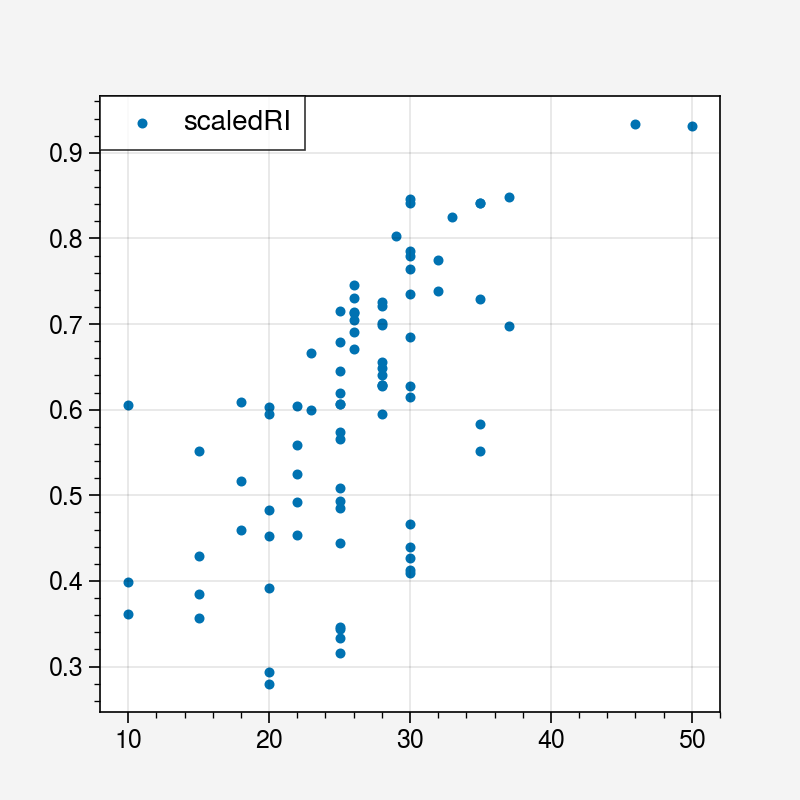

In [8]:
plot_data = culture_df2[culture_df2['GTDB_family'] == 'f__Nitrosopumilaceae']
plot_data = plot_data[plot_data['Broad Filtration Class']=='Total GDGTs']
plot_data_1 = plot_data[['sampleName','Source','reported_Temp','TEX86',
                         'ringIndex','scaledRI','gdgt23ratio','phyloT_order',
                        'GTDB_phylum','NCBI_phylum','GTDB_class','NCBI_class','GTDB_order','NCBI_order',
                        'GTDB_family','NCBI_family','Strains','experiment_setup','organism_broadClass','organism_broadClass2','organism_broadClass3',
                        'fGDGT_0', 'fGDGT_1', 'fGDGT_2', 'fGDGT_3', 'fGDGT_cren','fGDGT_cren_prime'
                        ]].rename(columns={'reported_Temp':'Temperature'})

temp_sampleID = ['TEXAS_PSM_culture_RR'+str(i).zfill(3) for i in range(1,len(plot_data_1)+1)]
plot_data_1.insert(0,'sampleID',temp_sampleID)
plot_data_1['datatype'] = 'culture'
plot_data_1['methaneIndex'] = np.sum(plot_data_1[['fGDGT_1', 'fGDGT_2', 'fGDGT_3']],axis=1)/np.sum(plot_data_1[['fGDGT_1','fGDGT_2','fGDGT_3', 'fGDGT_cren','fGDGT_cren_prime']],axis=1)
plot_data_1['gdgtZeroOverZeroCren'] = plot_data_1['fGDGT_0']/(plot_data_1['fGDGT_0'] + plot_data_1['fGDGT_cren'])
plot_data_1['BIT'] = 0
plot_data_1['violin_bins'] = plot_data_1['experiment_setup']+'_'+plot_data_1['organism_broadClass']

display(plot_data_1)
plt.scatter(plot_data_1['Temperature'],plot_data_1['scaledRI'],marker='.',label=r'scaledRI')
plt.legend(loc='best',fontsize=10)


,sampleID,sampleName,Source,Temperature,TEX86,ringIndex,scaledRI,gdgt23ratio,phyloT_order,GTDB_phylum,...,fGDGT_1,fGDGT_2,fGDGT_3,fGDGT_cren,fGDGT_cren_prime,datatype,methaneIndex,gdgtZeroOverZeroCren,BIT,violin_bins
55,TEXAS_PSM_culture_RR001,Elling2017_culture_ThAOA_totalGDGTs_Nitrosocal...,Elling et al. (2017) Environmnental Microbiology,72,0.612884,3.129260,0.782315,1.885747,25.1,p__Thermoproteota,...,0.050936,0.021266,0.011277,0.702391,0.048099,culture,0.100099,0.191187,0,culture-temperature_Terrestrial thermophile
56,TEXAS_PSM_culture_RR002,Elling2017_culture_ThAOA_totalGDGTs_Nitrososph...,Elling et al. (2017) Environmnental Microbiology,35,0.920575,3.640753,0.910188,0.907867,15.0,p__Thermoproteota,...,0.034385,0.040728,0.044861,0.534625,0.312957,culture,0.123998,0.057212,0,culture-temperature_Terrestrial thermophile
57,TEXAS_PSM_culture_RR003,Elling2017_culture_ThAOA_totalGDGTs_Nitrososph...,Elling et al. (2017) Environmnental Microbiology,46,0.966310,3.894759,0.973690,0.299016,15.0,p__Thermoproteota,...,0.011710,0.002984,0.009978,0.638877,0.322909,culture,0.025011,0.020756,0,culture-temperature_Terrestrial thermophile
58,TEXAS_PSM_culture_RR004,Pearson2008_027_Pure Cultures-Acidilobus sacch...,Pearson et al. (2008) Applied and Environmenta...,82,1.000000,3.000000,0.750000,0.000000,21.0,p__Thermoproteota,...,0.000000,0.000000,1.000000,0.000000,0.000000,culture,1.000000,NaN,0,culture-temperature_Terrestrial thermoacidophile
59,TEXAS_PSM_culture_RR005,Pearson2008_028_Pure Cultures-Metallosphaera s...,Pearson et al. (2008) Applied and Environmenta...,75,0.761905,1.942857,0.485714,0.920000,18.0,p__Thermoproteota,...,0.214286,0.328571,0.357143,0.000000,0.000000,culture,1.000000,1.000000,0,culture-temperature_Terrestrial thermoacidophile
60,TEXAS_PSM_culture_RR006,Pearson2008_029_Pure Cultures-Sulfolobus solfa...,Pearson et al. (2008) Applied and Environmenta...,85,0.947368,2.684211,0.671053,0.285714,19.0,p__Thermoproteota,...,0.052632,0.210526,0.736842,0.000000,0.000000,culture,1.000000,NaN,0,culture-temperature_Terrestrial thermoacidophile
61,TEXAS_PSM_culture_RR007,Pearson2008_030_Pure Cultures-Vulcanisaeta mou...,Pearson et al. (2008) Applied and Environmenta...,85,0.869565,2.111111,0.527778,0.428571,23.0,p__Thermoproteota,...,0.111111,0.222222,0.518519,0.000000,0.000000,culture,1.000000,1.000000,0,culture-temperature_Terrestrial hyperthermophilic
62,TEXAS_PSM_culture_RR008,Pearson2008_034_Pure Cultures-Thermoproteus uz...,Pearson et al. (2008) Applied and Environmenta...,85,0.875000,1.809524,0.452381,0.750000,22.0,p__Thermoproteota,...,0.095238,0.285714,0.380952,0.000000,0.000000,culture,1.000000,1.000000,0,culture-temperature_Terrestrial thermoacidophile
63,TEXAS_PSM_culture_RR009,Pearson2008_032_Pure Cultures-Desulfurococcus ...,Pearson et al. (2008) Applied and Environmenta...,85,0.830508,2.029412,0.507353,0.633333,20.0,p__Thermoproteota,...,0.147059,0.279412,0.441176,0.000000,0.000000,culture,1.000000,1.000000,0,culture-temperature_Terrestrial hyperthermophilic
64,TEXAS_PSM_culture_RR010,Pearson2008_033_Pure Cultures-Desulfurococcus ...,Pearson et al. (2008) Applied and Environmenta...,85,0.837838,1.955556,0.488889,0.550000,20.0,p__Thermoproteota,...,0.133333,0.244444,0.444444,0.000000,0.000000,culture,1.000000,1.000000,0,culture-temperature_Terrestrial hyperthermophilic


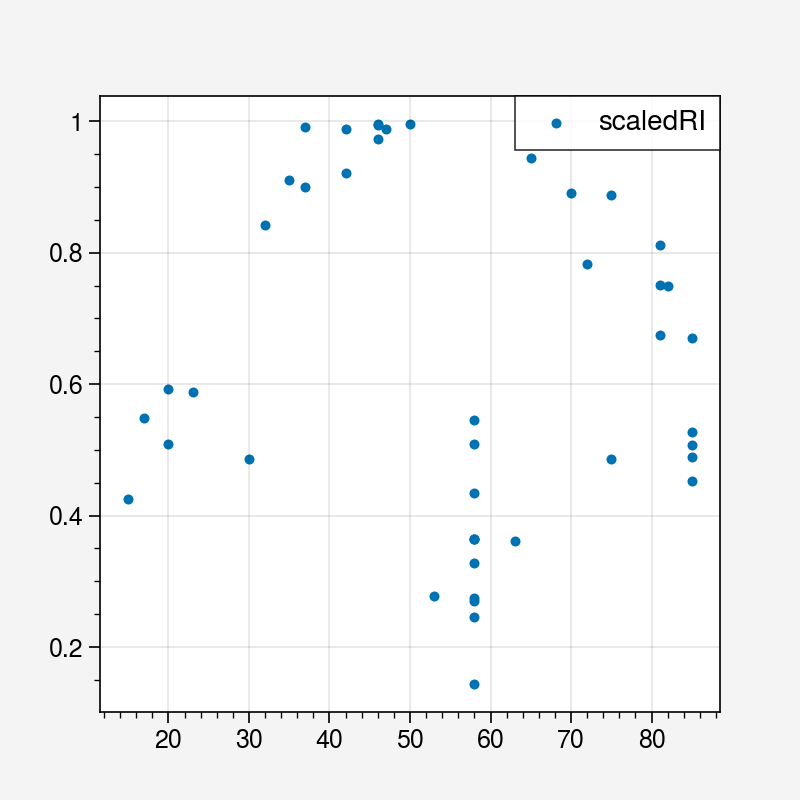

In [9]:
plot_data = culture_df2[culture_df2['GTDB_family'] != 'f__Nitrosopumilaceae']
plot_data = plot_data[plot_data['Broad Filtration Class']=='Total GDGTs']
plot_data_2 = plot_data[['sampleName','Source','reported_Temp','TEX86',
                         'ringIndex','scaledRI','gdgt23ratio','phyloT_order',
                        'GTDB_phylum','NCBI_phylum','GTDB_class','NCBI_class','GTDB_order','NCBI_order',
                        'GTDB_family','NCBI_family','Strains','experiment_setup','organism_broadClass','organism_broadClass2','organism_broadClass3',
                        'fGDGT_0', 'fGDGT_1', 'fGDGT_2', 'fGDGT_3', 'fGDGT_cren','fGDGT_cren_prime'
                        ]].rename(columns={'reported_Temp':'Temperature'})

temp_sampleID = ['TEXAS_PSM_culture_RR'+str(i).zfill(3) for i in range(1,len(plot_data_2)+1)]
plot_data_2.insert(0,'sampleID',temp_sampleID)
plot_data_2['datatype'] = 'culture'
plot_data_2['methaneIndex'] = np.sum(plot_data_2[['fGDGT_1', 'fGDGT_2', 'fGDGT_3']],axis=1)/np.sum(plot_data_2[['fGDGT_1','fGDGT_2','fGDGT_3', 'fGDGT_cren','fGDGT_cren_prime']],axis=1)
plot_data_2['gdgtZeroOverZeroCren'] = plot_data_2['fGDGT_0']/(plot_data_2['fGDGT_0'] + plot_data_2['fGDGT_cren'])
plot_data_2['BIT'] = 0
plot_data_2['violin_bins'] = plot_data_2['experiment_setup']+'_'+plot_data_2['organism_broadClass']

display(plot_data_2)
plt.scatter(plot_data_2['Temperature'],plot_data_2['scaledRI'],marker='.',label=r'scaledRI')
plt.legend(loc='best',fontsize=10)


,sampleID,sampleName,Source,Temperature,TEX86,ringIndex,scaledRI,gdgt23ratio,fGDGT_0,fGDGT_1,...,GTDB_classGTDB_family,NCBI_class,GTDB_order,NCBI_order,NCBI_family,Strains,experiment_setup,organism_broadClass,organism_broadClass2,organism_broadClass3
0,TEXAS_PSM_mesocosm_RR001,meso_001,Wuchter2004,10,0.334578,1.967739,0.491935,2.685656,0.416348,0.096573,...,mesocosm,mesocosm,mesocosm,mesocosm,mesocosm,mesocosm,mesocosm,mesocosm,mesocosm,mesocosm
1,TEXAS_PSM_mesocosm_RR002,meso_002,Wuchter2004,15,0.288381,1.939119,0.484780,2.190909,0.434734,0.088906,...,mesocosm,mesocosm,mesocosm,mesocosm,mesocosm,mesocosm,mesocosm,mesocosm,mesocosm,mesocosm
2,TEXAS_PSM_mesocosm_RR003,meso_003,Wuchter2004,15,0.239814,1.856318,0.464080,2.250000,0.451412,0.097281,...,mesocosm,mesocosm,mesocosm,mesocosm,mesocosm,mesocosm,mesocosm,mesocosm,mesocosm,mesocosm
3,TEXAS_PSM_mesocosm_RR004,meso_004,Wuchter2004,22,0.466403,2.991935,0.747984,2.858779,0.196237,0.051843,...,mesocosm,mesocosm,mesocosm,mesocosm,mesocosm,mesocosm,mesocosm,mesocosm,mesocosm,mesocosm
4,TEXAS_PSM_mesocosm_RR005,meso_005,Wuchter2004,25,0.461538,3.058343,0.764586,1.763466,0.193623,0.040726,...,mesocosm,mesocosm,mesocosm,mesocosm,mesocosm,mesocosm,mesocosm,mesocosm,mesocosm,mesocosm
5,TEXAS_PSM_mesocosm_RR006,meso_006,Wuchter2004,25,0.483547,3.228140,0.807035,3.037383,0.145988,0.043298,...,mesocosm,mesocosm,mesocosm,mesocosm,mesocosm,mesocosm,mesocosm,mesocosm,mesocosm,mesocosm
6,TEXAS_PSM_mesocosm_RR007,meso_007,Wuchter2004,30,0.527554,3.043329,0.760832,4.415385,0.153019,0.071979,...,mesocosm,mesocosm,mesocosm,mesocosm,mesocosm,mesocosm,mesocosm,mesocosm,mesocosm,mesocosm
7,TEXAS_PSM_mesocosm_RR008,meso_008,Wuchter2004,35,0.705459,3.162726,0.790682,5.052474,0.108380,0.057469,...,mesocosm,mesocosm,mesocosm,mesocosm,mesocosm,mesocosm,mesocosm,mesocosm,mesocosm,mesocosm
8,TEXAS_PSM_mesocosm_RR009,meso_009,Wuchter2004,13,0.263181,1.874010,0.468502,2.705674,0.480893,0.057159,...,mesocosm,mesocosm,mesocosm,mesocosm,mesocosm,mesocosm,mesocosm,mesocosm,mesocosm,mesocosm
9,TEXAS_PSM_mesocosm_RR010,meso_010,Wuchter2004,15,0.309940,2.180438,0.545109,2.971429,0.371221,0.090714,...,mesocosm,mesocosm,mesocosm,mesocosm,mesocosm,mesocosm,mesocosm,mesocosm,mesocosm,mesocosm


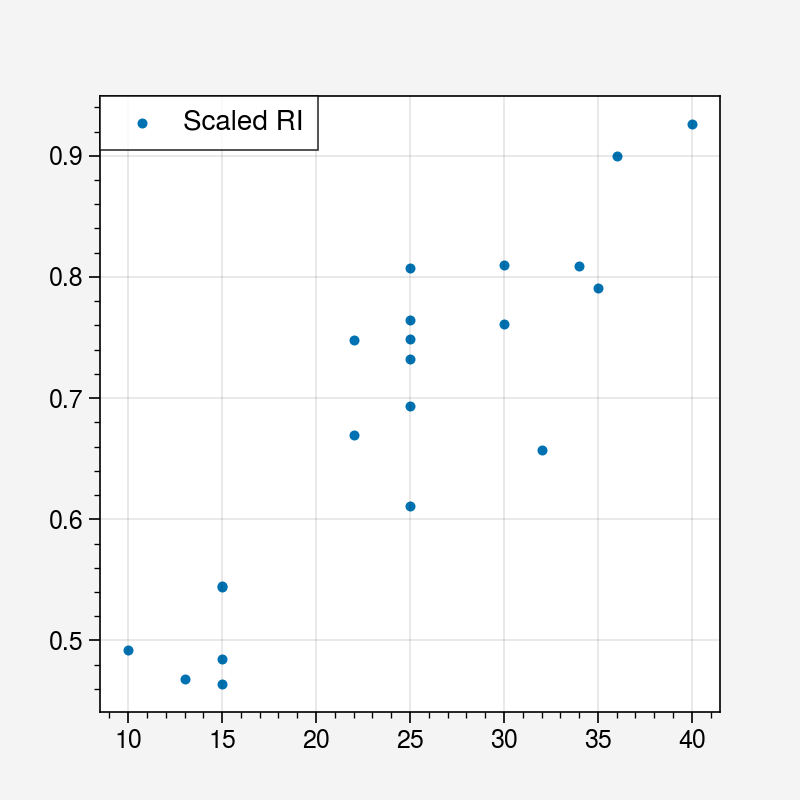

In [10]:
features = ['fGDGT_0', 'fGDGT_1', 'fGDGT_2', 'fGDGT_3','fGDGT_cren', 'fGDGT_cren_prime']
mesocosm_df['ringIndex'] = np.array([mesocosm_df[features[i]]*ringNumbers_dict_zhang16.get(features[i]) for i in range(len(features))]).sum(axis=0)
mesocosm_df['scaledRI'] = mesocosm_df['ringIndex']/4
mesocosm_df['gdgt23ratio'] = mesocosm_df['fGDGT_2']/mesocosm_df['fGDGT_3']
mesocosm_df['sampleName'] = ['meso_'+f'{i+1}'.zfill(3) for i in range(len(mesocosm_df))]
plot_data_3 = mesocosm_df[['sampleName','Source','Temperature','tex86',
                           'ringIndex','scaledRI','gdgt23ratio',   
                           'fGDGT_0', 'fGDGT_1', 'fGDGT_2', 'fGDGT_3',
                           'fGDGT_cren', 'fGDGT_cren_prime']].rename(columns={
                                                                        'tex86':'TEX86',
                                                                        })

temp_sampleID = ['TEXAS_PSM_mesocosm_RR'+str(i).zfill(3) for i in range(1,len(plot_data_3)+1)]
plot_data_3.insert(0,'sampleID',temp_sampleID)
plot_data_3['datatype'] = 'mesocosm'
plot_data_3['methaneIndex'] = np.sum(plot_data_3[['fGDGT_1','fGDGT_2','fGDGT_3']],axis=1)/np.sum(plot_data_3[['fGDGT_1','fGDGT_2','fGDGT_3','fGDGT_cren','fGDGT_cren_prime']],axis=1)
plot_data_3['gdgtZeroOverZeroCren'] = plot_data_3['fGDGT_0']/(plot_data_3['fGDGT_0'] + plot_data_3['fGDGT_cren'])
plot_data_3['BIT'] = 0
plot_data_3['phyloT_order'] = 0
new_cols = [
    'GTDB_phylum','NCBI_phylum','GTDB_class''GTDB_family',
    'NCBI_class','GTDB_order','NCBI_order','NCBI_family','Strains','experiment_setup',
    'organism_broadClass','organism_broadClass2','organism_broadClass3']
for col in new_cols:
    plot_data_3[col] = 'mesocosm'
    

display(plot_data_3)
plt.scatter(plot_data_3['Temperature'],plot_data_3['scaledRI'],marker='.',label=r'Scaled RI')
plt.legend(loc='upper left',fontsize=10)

In [11]:
merged_df = pd.concat([plot_data_1,plot_data_2,plot_data_3],axis=0)
display(merged_df)

fpath = os.path.join(local_github_path,'spreadsheets')
fname = r'culture_mesocosm_combined_rev_030425.csv'
merged_df.to_csv(os.path.join(fpath,fname),index=False)

,sampleID,sampleName,Source,Temperature,TEX86,ringIndex,scaledRI,gdgt23ratio,phyloT_order,GTDB_phylum,...,fGDGT_2,fGDGT_3,fGDGT_cren,fGDGT_cren_prime,datatype,methaneIndex,gdgtZeroOverZeroCren,BIT,violin_bins,GTDB_classGTDB_family
17,TEXAS_PSM_culture_RR001,Bale2019_019_Cultures_ThAOA_Ca Nitrosotenuis u...,Bale et al. (2019) AEM,37,0.578544,2.792553,0.698138,0.478873,13.0,p__Thermoproteota,...,0.060284,0.125887,0.443262,0.081560,culture,0.420744,0.174917,0,culture-temperature_Terrestrial thermophile,NaN
18,TEXAS_PSM_culture_RR002,Bale2019_020_Cultures_ThAOA_Ca Nitrosotenuis u...,Bale et al. (2019) AEM,46,0.806931,3.734637,0.933659,0.482759,13.0,p__Thermoproteota,...,0.019553,0.040503,0.712291,0.167598,culture,0.115169,0.007782,0,culture-temperature_Terrestrial thermophile,NaN
19,TEXAS_PSM_culture_RR003,Bale2019_021_Cultures_ThAOA_Ca Nitrosotenuis u...,Bale et al. (2019) AEM,50,0.755102,3.725664,0.931416,0.652174,13.0,p__Thermoproteota,...,0.018963,0.029077,0.745891,0.139064,culture,0.109415,0.008403,0,culture-temperature_Terrestrial thermophile,NaN
20,TEXAS_PSM_culture_RR004,Elling2015_Culture_NA0A2_18,Elling et al. (2015) GCA,18,0.858108,2.437576,0.609394,0.402266,5.2,p__Thermoproteota,...,0.172121,0.427879,0.161212,0.015758,culture,0.798621,0.429185,0,culture-temperature_Marine mesophile,NaN
21,TEXAS_PSM_culture_RR005,Elling2015_Culture_NA0A2_22,Elling et al. (2015) GCA,22,0.827338,2.235429,0.558857,1.088785,5.2,p__Thermoproteota,...,0.266286,0.244571,0.200000,0.014857,culture,0.742818,0.451411,0,culture-temperature_Marine mesophile,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16,TEXAS_PSM_mesocosm_RR017,meso_017,Schouten2007,25,0.449778,2.772491,0.693123,2.629108,0.0,mesocosm,...,0.035219,0.013396,0.635200,0.011792,mesocosm,0.159209,0.266255,0,NaN,mesocosm
17,TEXAS_PSM_mesocosm_RR018,meso_018,Schouten2007,32,0.683519,2.627887,0.656972,3.553719,0.0,mesocosm,...,0.055801,0.015702,0.564495,0.039904,mesocosm,0.169194,0.325581,0,NaN,mesocosm
18,TEXAS_PSM_mesocosm_RR019,meso_019,Schouten2007,34,0.606766,3.236153,0.809038,2.318038,0.0,mesocosm,...,0.045612,0.019677,0.747221,0.011769,mesocosm,0.131807,0.144080,0,NaN,mesocosm
19,TEXAS_PSM_mesocosm_RR020,meso_020,Schouten2007,36,0.813041,3.598787,0.899697,2.396907,0.0,mesocosm,...,0.054250,0.022633,0.822493,0.027125,mesocosm,0.106058,0.056856,0,NaN,mesocosm


## 2.2 Coretop compilation

In [ ]:
fpath = os.path.join(local_github_path,'spreadsheets')
fname = r'ds01_updated_global_coretop_tex.csv'

coretop_df = pd.read_csv(os.path.join(fpath,fname))

coretop_df = coretop_df.rename(
    columns={
        'latitude':'Latitude',
        'longitude':'Longitude',
        'depth':'modernWaterDepth',
        'tex86':'TEX86',
        'bit':'BIT'
    }
)

#### Additional parameters
coretop_df['publicationYear'] = [int(row[-4:]) if row[-4:].isdigit() else 'This Study' for row in coretop_df['reference_name']]
Tierney2015SciAdv_idx = coretop_df[coretop_df['reference_name']=='Tierney2015SciAdv'].index
coretop_df.loc[Tierney2015SciAdv_idx,'publicationYear'] = 2015
thisStudy_idx = coretop_df[coretop_df['publicationYear']=='This Study'].index
coretop_df.loc[thisStudy_idx,'publicationYear'] = 2025
coretop_df['publicationYear'] = coretop_df['publicationYear'].astype(int)
features = ['fGDGT_0', 'fGDGT_1', 'fGDGT_2', 'fGDGT_3','fGDGT_cren', 'fGDGT_cren_prime']
coretop_df['ringIndex'] = np.array([coretop_df[features[i]]*ringNumbers_dict_zhang16.get(features[i]) for i in range(len(features))]).sum(axis=0)
coretop_df['gdgt23ratio'] = coretop_df['fGDGT_2']/coretop_df['fGDGT_3']
coretop_df['methaneIndex'] = coretop_df[['fGDGT_1', 'fGDGT_2', 'fGDGT_3']].sum(axis=1)/coretop_df[['fGDGT_1', 'fGDGT_2', 'fGDGT_3','fGDGT_cren', 'fGDGT_cren_prime']].sum(axis=1)
coretop_df['gdgtZeroOverZeroCren'] = (coretop_df['fGDGT_0']/coretop_df[['fGDGT_0','fGDGT_cren']].sum(axis=1))

temp_sampleID = ['RR'+str(i).zfill(5) for i in range(1,len(coretop_df)+1)]
coretop_df.insert(0,'sampleID',temp_sampleID)

#### copy coretop_df to coretop_df2 to keep the original df
coretop_df2 = coretop_df.dropna(how='any', subset=['TEX86']).reset_index(drop=True)
coretop_df2['BIT'] = coretop_df2['BIT'].fillna(-999)
coretop_df2['methaneIndex']= coretop_df2['methaneIndex'].fillna(-999)
coretop_df2['gdgtZeroOverZeroCren'] = coretop_df2['fGDGT_0'].fillna(-999)

coretop_df2['TEX_RI'] = (-0.77*coretop_df2['TEX86']
                                )+(3.32*coretop_df2['TEX86']**2
                                   )+(1.59)
coretop_df2['deltaRI'] = coretop_df2['TEX_RI']-coretop_df2['ringIndex']


coretop_df2['QC_flag'] = ['include' if ((coretop_df2['BIT'].iloc[i] <= 0.5) & (coretop_df2['methaneIndex'].iloc[i] <= 0.5) & (coretop_df2['gdgtZeroOverZeroCren'].iloc[i] <= 0.67)) else 'exclude' for i in range(len(coretop_df2))]
coretop_df2

## 2.3 Ocean products

### 2.3.1 WOA23 - Temperature 0.25deg x 0.25deg

WOA = World Ocean Atlas
Details:
- Temperature - Statistical mean on 1/4° grid for 1991-2020 climate normal
- Unit: Degree Celcius
- Link to download data: https://www.ncei.noaa.gov/thredds-ocean/fileServer/woa23/DATA/temperature/netcdf/decav91C0/0.25/woa23_decav91C0_t00_04.nc

In [ ]:
fpath2 = fr'{local_documents_path}/Postdoc/TEXAS-PSM/netcdf/WOA-database/WOA23/WOA-decav'
ts = xr.open_dataset(os.path.join(fpath2,'woa23_decav91C0_t00_04.nc'),decode_times=False).drop('time')

T_da = ts.isel(time=0).t_an.load()
T_da

#### Calculate gridded thermocline depth and depth-integrated thermocline T with xarray

In [ ]:
### calculate thermocline along depth dimension of T_da using min T gradient approach (depth with the fastest drop in T)
### calculate using diff method from xarray and divide by the diff of depth
sliced_T_da = T_da.sel(depth=slice(0,1100))
gradient = sliced_T_da.diff('depth')/sliced_T_da.depth.diff('depth')

### mask NaN values
gradient = abs(gradient.where(~np.isnan(T_da)))

### fill NaN values with infinity to avoid error in argmin
gradient_filled = gradient.fillna(-np.inf)
maxabs_gradient_idx = gradient_filled.argmax('depth',skipna=True).astype(int)+1

### mask locations where all depth values are NaN
all_nan_mask = np.isnan(sliced_T_da).all('depth')

### mask maxabs_gradient_idx where all depth values are NaN
maxabs_gradient_idx = maxabs_gradient_idx.where(~all_nan_mask, drop=False)

# Flatten the lat-lon grid for advanced indexing
stacked = sliced_T_da.stack(grid=["lat", "lon"])

# Ensure maxabs_gradient_idx is an integer, replacing NaN with a valid placeholder index (e.g., 0)
valid_idx = maxabs_gradient_idx.fillna(0).astype(int)

# Use isel to index the depth dimension with the flattened indices
thermoT_depth_values = stacked["depth"].isel(depth=valid_idx.stack(grid=["lat", "lon"]))
thermoT_values = stacked.isel(depth=valid_idx.stack(grid=["lat", "lon"]))
# Mask locations where maxabs_gradient_idx was NaN
nan_mask = maxabs_gradient_idx.isnull()
thermoT_depth_values = thermoT_depth_values.where(~nan_mask.stack(grid=["lat", "lon"]))
thermoT_values = thermoT_values.where(~nan_mask.stack(grid=["lat", "lon"]))
# Unstack to return to the original lat-lon dimensions
thermoT_depth_da = thermoT_depth_values.unstack("grid")
thermoT_da = thermoT_values.unstack("grid")
masked_T_da = T_da.where(T_da["depth"]<=thermoT_depth_da)


In [ ]:
len_notnull_values_along_depth = np.unique(masked_T_da.notnull().sum('depth').values)
sel_masked_da = masked_T_da
tmp_da = xr.DataArray(np.zeros_like(sel_masked_da.isel(depth=0).values),
                      dims=sel_masked_da.isel(depth=0).dims,
                      coords=sel_masked_da.isel(depth=0).coords
                      )
tmp_da
# Loop through the unique counts of non-NaN values along depth
for i in len_notnull_values_along_depth:
    if i == 0:
        continue  # Skip cases where no valid data is available
    # Select grid points where the non-NaN count equals `i`
    mask = sel_masked_da.notnull().sum('depth') == i
    
    if i == 1:
        # if only one valid depth slice, use the first depth slice
        cal_values = (
            sel_masked_da.where(sel_masked_da.notnull().sum('depth') == i)
            .isel(depth=0)
        )
    else:
        # Calculate the integrated values for the valid depth slices
        cal_values = (
            sel_masked_da.where(sel_masked_da.notnull().sum('depth') == i)
            .isel(depth=slice(0, i))
            .integrate('depth')
        )
        
        # Update tmp_da with the calculated values at the same grid points
    tmp_da = tmp_da.where(~mask, other=cal_values)
tmp_da2 = tmp_da
#### mask locations where there are more than 1 valid depth values
mask_below_SST = sel_masked_da.notnull().sum('depth') > 1
cal_values = tmp_da2.where(mask_below_SST)/thermoT_depth_da.where(mask_below_SST)
# apply mask where all depth values are NaN
all_nan_mask = np.isnan(sel_masked_da).all('depth')
tmp_da2 = tmp_da2.where(~all_nan_mask)

thermocline_depthIntegral_T_da = tmp_da2.where(~mask_below_SST, other=cal_values)
thermocline_depthIntegral_T_da

#### Spot-checking core sites near coastlines

In [ ]:
fig, axs = plot.subplots(proj='eck3',width=10,ncols=2)
axs.format(
    latlim=(15,20),
    lonlim=(35,45),
    latlabels=True,lonlabels=True
)

ax = axs[0]
thermocline_depthIntegral_T_da.plot(ax=ax,robust=True,
                                    cmap=cmo.thermal,
                                    levels=np.arange(-4,30,2),
                                    cbar_kwargs={'label':'Temperature (°C)'}
                                    )

ax.scatter(coretop_df2['Longitude'],coretop_df2['Latitude'],s=10,c='k',marker='x',label='Coretops')

ax = axs[1]
thermoT_depth_da.plot(ax=ax,robust=True,
                cmap=cmo.deep,
                levels=np.arange(0,200,10),
                cbar_kwargs={'label':'Depth (m)'}
                )

ax.scatter(coretop_df2['Longitude'],coretop_df2['Latitude'],s=10,c='k',marker='x',label='Coretops')
ax.scatter(41,18)

### 2.3.2 CMEMS Nitrate

CMEMS = Copernicus Marine Environmental Monitoring Service

- Nitrate - Mole concentration of nitrate in sea water 0.25deg x 0.25deg
- Unit: mmol/m3
- Link to data product website: https://data.marine.copernicus.eu/product/GLOBAL_MULTIYEAR_BGC_001_029/description

- Raw data: monthly climatology hindcasts from 1993-2022 (30 years)
- Processing: The climatology mean field of annual average were generated from 30-year montly climatologies using ncclimo function (https://nco.sourceforge.net/nco.html)

In [ ]:
### NEMO nitrate data
fpath = fr'{local_documents_path}/Postdoc/TEXAS-PSM/netcdf/Marine-Copernicus-Service/processed-files/Global-Biogeochemistry/climo-monthly/no3'
fname = r'mercatorfreebiorys2v4_global_mean_ANN_199301_202212_climo.nc'

nitrate_CMEMS_ds = xr.open_dataset(os.path.join(fpath,fname))
nitrate_CMEMS_ds = nitrate_CMEMS_ds.isel(time=0).drop('time')
nitrate_CMEMS_ds = nitrate_CMEMS_ds.rename({'latitude':'lat','longitude':'lon'})
nitrate_CMEMS_da = nitrate_CMEMS_ds.no3.load() ### convert mmol/L to umol/L to make it comparable to WOA data
nitrate_CMEMS_da

depth_coord = nitrate_CMEMS_da.depth
depth_coord = depth_coord - depth_coord[0]
nitrate_CMEMS_da = nitrate_CMEMS_da.assign_coords(depth=depth_coord)
nitrate_CMEMS_da

In [ ]:
### regrid nitrate_CMESM to T_an grid
nitrate_CMEMS_da_regrid_lld = nitrate_CMEMS_da.interp(lat=T_da.lat,lon=T_da.lon,depth=T_da.depth,method='linear')
nitrate_CMEMS_da_regrid_lld 

In [ ]:
masked_nitrate_regrid_lld_da = nitrate_CMEMS_da_regrid_lld.where(nitrate_CMEMS_da_regrid_lld["depth"]<=thermoT_depth_da)
masked_tmp_grid = masked_nitrate_regrid_lld_da
len_notnull_values_along_depth = np.unique(masked_tmp_grid.notnull().sum('depth').values)
tmp_da = xr.DataArray(np.zeros_like(masked_tmp_grid.isel(depth=0).values),
                      dims=masked_tmp_grid.isel(depth=0).dims,
                      coords=masked_tmp_grid.isel(depth=0).coords
                      )
tmp_da2 = xr.DataArray(np.zeros_like(masked_tmp_grid.isel(depth=0).values),
                        dims=masked_tmp_grid.isel(depth=0).dims,
                        coords=masked_tmp_grid.isel(depth=0).coords
                        )
# Loop through the unique counts of non-NaN values along depth
for i in len_notnull_values_along_depth:
    if i == 0:
        continue  # Skip cases where no valid data is available
    # Select grid points where the non-NaN count equals `i`
    mask = masked_tmp_grid.notnull().sum('depth') == i
    
    if i == 1:
        # if only one valid depth slice, use the first depth slice
        cal_values = (
            masked_tmp_grid.where(masked_tmp_grid.notnull().sum('depth') == i)
            .isel(depth=0)
        )
        cal_values2 = (
            masked_tmp_grid.where(masked_tmp_grid.notnull().sum('depth') == i)
            .isel(depth=0)
        )
    else:
        # Calculate the integrated values for the valid depth slices
        cal_values = (
            masked_tmp_grid.where(masked_tmp_grid.notnull().sum('depth') == i)
            .isel(depth=slice(0, i))
            .integrate('depth')
        )
        ### grab last value of nitrate
        cal_values2 = (
            masked_tmp_grid.where(masked_tmp_grid.notnull().sum('depth') == i)
            .isel(depth=slice(0, i))
            .isel(depth=i-1)
        )
    # Update tmp_da with the calculated values at the same grid points
    tmp_da = tmp_da.where(~mask, other=cal_values)
    tmp_da2 = tmp_da2.where(~mask, other=cal_values2)

#### mask locations where there are more than 1 valid depth values
mask_below_surface = masked_tmp_grid.notnull().sum('depth') > 1
cal_values = tmp_da.where(mask_below_surface)/thermoT_depth_da.where(mask_below_surface)

# apply mask where all depth values are NaN
all_nan_mask = np.isnan(masked_tmp_grid).all('depth')
tmp_da = tmp_da.where(~all_nan_mask)
thermocline_depthIntegral_nitrate_da = tmp_da
thermocline_depthIntegral_nitrate_da = thermocline_depthIntegral_nitrate_da.where(~mask_below_surface, other=cal_values)
display(thermocline_depthIntegral_nitrate_da)

tmp_da2 = tmp_da2.where(~all_nan_mask)
thermocline_nitrate_da = tmp_da2
display(thermocline_nitrate_da)


In [ ]:
fig, axs = plot.subplots(nrows=2,figsize=(8,6))
sel_lon = -30
ax = axs[0]
nitrate_CMEMS_da.sel(lon=sel_lon,method='nearest').plot(ax=ax)


ax = axs[1]
nitrate_CMEMS_da_regrid_lld.sel(lon=sel_lon,method='nearest').plot(ax=ax)

axs.format(
    yreverse=True,
)

### 2.3.3 Export calculated calculated ocean properties as netcdf file

In [ ]:
thermocline_depthIntegral_nitrate_da_final = thermocline_depthIntegral_nitrate_da.drop('depth').rename('no3_sf2tc_avg')
thermocline_depthIntegral_nitrate_da_final = thermocline_depthIntegral_nitrate_da_final.assign_attrs({
    'long_name': 'Surface-to-thermocline (sf2tc) Average Nitrate Concentration',
    'standard_name': 'mole_concentration_of_nitrate_in_sea_water',
    'units': 'mmol m-3 (equivalent to umol L-1)',
    'unit_long': 'Millimoles of nitrate per cubic meter of seawater (equivalent to micromoles per liter)',
    'valid_min': 0,
    'valid_max': 67.14648,
    'cell_methods': (
        '''Climatological annual means (1993–2022) derived from monthly climatologies of ocean nitrate concentrations (Global Ocean Biogeochemistry Hindcast data, CMEMS). The surface-to-thermocline average is computed by averaging values from the surface down to the thermocline, where thermocline depths are determined from WOA23 temperature data as the depth of maximum temperature gradient.'''
    ),
})

thermocline_nitrate_da_final = thermocline_nitrate_da.drop('depth').rename('no3_tc')
thermocline_niutrate_da_final = thermocline_nitrate_da_final.assign_attrs({
    'long_name': 'thermocline (tc) nitrate concentrations',
    'standard_name': 'mole_concentration_of_nitrate_in_sea_water',
    'units': 'mmol m-3 (equivalent to umol L-1)',
    'unit_long': 
        'Millimoles of nitrate per cubic meter of seawater (equivalent to micromoles per liter)',
    'valid_min': 0,
    'valid_max': 63.185028,
    'cell_methods': 
        '''Climatological annual means (1993–2022) derived from monthly climatologies of ocean nitrate concentrations (Global Ocean Biogeochemistry Hindcast data, CMEMS). The thermocline nitrate is retrieved from thermocline depths, determining by WOA23 temperature data as the depth of maximum temperature gradient.''',})


thermocline_depthIntegral_T_da_final = thermocline_depthIntegral_T_da.drop('depth').rename('t_sf2tc_avg')
thermocline_depthIntegral_T_da_final = thermocline_depthIntegral_T_da_final.assign_attrs({
    'long_name': 'Surface-to-thermocline (sf2tc) Average Temperature',
    'standard_name': 'sea_water_temperature',
    'units': '°C',
    'unit_long': 'Degrees Celsius',
    'valid_min': -1.8823541,
    'valid_max': 30.744995,
    'cell_methods':
        '''The surface-to-thermocline average is computed from the WOA23 temperature data by averaging values from the surface down to the thermocline, where thermocline depths are determined from WOA23 temperature data as the depth of maximum temperature gradient.''',})


thermoT_depth_da_final = thermoT_depth_da.drop('depth').rename('tc_depth')
thermoT_depth_da_final = thermoT_depth_da_final.assign_attrs({
    'long_name': 'Thermocline Depth',
    'standard_name': 'depth',
    'units': 'm',
    'unit_long': 'meters',
    'valid_min': 5.,
    'valid_max': 1050.,
    'cell_methods':
        '''The thermocline depth is determined from WOA23 temperature data as the depth of maximum temperature gradient.''',})
thermoT_da_final = thermoT_da.drop('depth').rename('t_tc')
thermoT_da_final = thermoT_da_final.assign_attrs({
    'long_name': 'Thermocline Temperature',
    'standard_name': 'sea_water_temperature',
    'units': '°C',
    'unit_long': 'Degrees Celsius',
    'valid_min': -2.08761,
    'valid_max': 29.96029,
    'cell_methods':
        '''The thermocline temperature is retrieved from thermocline depths, determining by WOA23 temperature data as the depth of maximum temperature gradient.''',})

### combine all dataarrays into a single dataset and save as ds06_calculated_ocean_properties.nc

cal_ocean_props_ds = xr.merge([thermocline_depthIntegral_nitrate_da_final,
                 thermocline_nitrate_da_final,
                 thermocline_depthIntegral_T_da_final,
                 thermoT_depth_da_final,thermoT_da_final],combine_attrs="drop")
cal_ocean_props_ds = cal_ocean_props_ds.assign_attrs({
    'title': 'Calculated Ocean Properties: Nitrite and Temperature from Surface to Thermocline',
    'summary': (
        '''This dataset contains climatological annual means (1993–2022) derived from monthly climatologies of ocean properties. The variables included are: 
        no2_sf2tc_avg: surface-to-thermocline average nitrite concentration
        no2_tc: nitrite concentration at the thermocline
        t_sf2tc_avg: surface-to-thermocline average sea water temperature
        t_tc: sea water temperature at the thermocline 
        tc_depth: thermocline depth
        '''
    ),
    'data_sources': 'Global Ocean Biogeochemistry Hindcast (CMEMS); World Ocean Atlas 2023 (WOA23)',
    'Conventions': 'CF-1.7',
    'processing_level': 'Derived product',
    'history': 
        '''(a) Nitrate: Calculated climatological annual means (1993–2022) from monthly climatologies. (b) Temperature: Calculated from climatological annual means (1991–2020) of WOA23 temperature data.
        ''',
    'Conventions': 'CF-1.7',
    'references': 'CMEMS, WOA23'
})
cal_ocean_props_ds

In [ ]:
### save ds06 to netcdf with name ds06_calculated_ocean_properties.nc
fpath = os.path.join(local_github_path,'nc_files')
fname = 'calculated_ocean_properties.nc'
cal_ocean_props_ds.to_netcdf(os.path.join(fpath,fname))

# 3. Pre-processing

## 3.0 Match gridded lat, lon, depth

In [ ]:
mid_lat_array = T_da.lat.values
mid_lon_array = T_da.lon.values
depth_array = T_da.depth.values
coretop_df2['match_lat'] = [mid_lat_array[np.abs(mid_lat_array-row).argmin()] for row in coretop_df2['Latitude']]
coretop_df2['match_lon'] = [mid_lon_array[np.abs(mid_lon_array-row).argmin()] for row in coretop_df2['Longitude']]
coretop_df2['match_depth'] = [depth_array[np.abs(depth_array-row).argmin()] for row in coretop_df2['modernWaterDepth']]

## 3.1 Temperature and thermoclines

In [ ]:
##### Calculated clines depth and integrated and weighted integral values
coretop_df2['SST'] = [np.atleast_1d(T_da.isel(depth=0).sel(lat=coretop_df2['Latitude'].iloc[i],lon=coretop_df2['Longitude'].iloc[i],
                               method='nearest').values)[0] for i in range(len(coretop_df2))]
coretop_df2['thermocline_depth'] = [np.atleast_1d(cal_ocean_props_ds.tc_depth.sel(lat=coretop_df2['Latitude'].iloc[i],lon=coretop_df2['Longitude'].iloc[i],
                                 method='nearest').values)[0] for i in range(len(coretop_df2))]
coretop_df2['thermocline_T'] = [np.atleast_1d(cal_ocean_props_ds.t_tc.sel(lat=coretop_df2['Latitude'].iloc[i],lon=coretop_df2['Longitude'].iloc[i],
                                 method='nearest').values)[0] for i in range(len(coretop_df2))]
coretop_df2['thermocline_T_depthIntegral'] = [np.atleast_1d(cal_ocean_props_ds.t_sf2tc_avg.sel(lat=coretop_df2['Latitude'].iloc[i],
                                                                                lon=coretop_df2['Longitude'].iloc[i],
                                                                                method='nearest').values)[0] for i in range(len(coretop_df2))]
    
coretop_df2

## 3.2 Nitrate concentrations

In [ ]:
### calculate integrated nitrate values to the thermocline depth
coretop_df2['SSN'] = [nitrate_CMEMS_da_regrid_lld.isel(depth=0).sel(lat=coretop_df2['Latitude'].iloc[i],
                                                                    lon=coretop_df2['Longitude'].iloc[i],
                                                                    method='nearest').values for i in range(len(coretop_df2))]

coretop_df2['thermocline_nitrate'] = [cal_ocean_props_ds.no3_tc.sel(lat=coretop_df2['Latitude'].iloc[i],
                                                                lon=coretop_df2['Longitude'].iloc[i],
                                                                method='nearest').values for i in range(len(coretop_df2))]
coretop_df2['thermocline_nitrate_depthIntegral'] = [cal_ocean_props_ds.no3_sf2tc_avg.sel(lat=coretop_df2['Latitude'].iloc[i],
                                                                                            lon=coretop_df2['Longitude'].iloc[i],
                                                                                            method='nearest').values for i in range(len(coretop_df2))]

coretop_df2

# 4. Gridded coretop TEX

In [ ]:
new_features = ['RI_count','RI_median','RI_mean','RI_std']
agg_func_list = ['count','median','mean','std']

features = ['match_lon','match_lat','ringIndex','thermocline_T_depthIntegral']
coretop_df_pregridded = coretop_df2[coretop_df2['QC_flag']=='include'][features]
coretop_df_pregridded = coretop_df_pregridded.dropna(subset=['ringIndex','thermocline_T_depthIntegral']).reset_index(drop=True)
for i in range(len(new_features)):
    feature = new_features[i]
    coretop_df_pregridded[feature] = coretop_df_pregridded.groupby(['match_lon','match_lat'])['ringIndex'].transform(agg_func_list[i])

coretop_df_pregridded = coretop_df_pregridded.drop_duplicates(
    subset=['match_lon','match_lat'],keep='first',)

coretop_gridded_ds = xr.Dataset.from_dataframe(coretop_df_pregridded.set_index(['match_lon','match_lat']))
coretop_gridded_ds = coretop_gridded_ds.rename({'match_lon':'lon','match_lat':'lat'})

### nan mask
nan_mask = coretop_gridded_ds['RI_median'].isnull()
coretop_gridded_ds = coretop_gridded_ds.where(~nan_mask,drop=True)

### convert depth coord to var
thermoT_depth_da_var = thermoT_depth_da.to_dataset(name='thermocline_depth')
thermoT_depth_da_var = thermoT_depth_da_var.assign_coords({'lon':thermoT_depth_da_var['lon'].values,
                                                              'lat':thermoT_depth_da_var['lat'].values}
                                                          ).reset_coords('depth', drop=True)

### combine all dataarrays into a single dataset
thermocline_depthIntegral_T_da_final

merge_ds_list = [thermocline_depthIntegral_T_da_final,coretop_gridded_ds]

merge_ds_list_new = []
for da_ in merge_ds_list:
    ### check if 'depth' is in the coordinates
    if 'depth' in da_.coords:
        da_ = da_.reset_coords('depth', drop=True)
    elif 'time' in da_.coords:
        da_ = da_.reset_coords('time', drop=True)
    merge_ds_list_new.append(da_)
        


merged_ds = xr.merge(merge_ds_list_new)

### linear fit between sst and RI_median
reg_data = merged_ds.stack(grid=['lat','lon'])
sel_x_param = 't_sf2tc_avg'
sel_y_param = 'RI_median'
nonnan_grid_idx = (~np.isnan(reg_data[sel_x_param])) & (~np.isnan(reg_data[sel_y_param]))

ols = LinearRegression()
XX = reg_data[sel_x_param].values[nonnan_grid_idx].reshape(-1,1)
yy = reg_data[sel_y_param].values[nonnan_grid_idx]
ols.fit(XX,yy)
slope = ols.coef_[0]
intercept = ols.intercept_


coretop_df_pregridded['pred_RI_ols'] = ols.predict(coretop_df_pregridded['thermocline_T_depthIntegral'].values.reshape(-1,1))
coretop_df_pregridded['RI_residuals_ols'] = coretop_df_pregridded['RI_median']-coretop_df_pregridded['pred_RI_ols']

###### calculate residuals for the original coretop_df2
coretop_df2['pred_RI_ols'] = slope*coretop_df2['thermocline_T_depthIntegral']+intercept
coretop_df2['RI_residuals_ols'] = coretop_df2['ringIndex']-coretop_df2['pred_RI_ols']

coretop_gridded_ds2 = xr.Dataset.from_dataframe(coretop_df_pregridded[['match_lon','match_lat',
                                                                       'RI_residuals_ols']].set_index(['match_lon','match_lat']))
coretop_gridded_ds2 = coretop_gridded_ds2.rename({'match_lon':'lon','match_lat':'lat'})

gridded_coretop_RI_ds = xr.merge([merged_ds,coretop_gridded_ds2 ],combine_attrs="drop")
gridded_coretop_RI_ds = gridded_coretop_RI_ds.drop_vars(['t_sf2tc_avg','thermocline_T_depthIntegral','ringIndex'])
######## Write dataset attributes to describe the dataset in netcdf file
gridded_coretop_RI_ds = gridded_coretop_RI_ds.assign_attrs({
    'title':'Gridded coretop RI data',
    'long_name':'statistics of RI for each grid cell with the same lat-lon dimensions as WOA23 data 0.25x0.25 degree grid',
    'units':'RI [unitless], thermocline-integrated T [degC], depth [m]',
    'summary': (
        '''This dataset contains climatological annual means (1993–2022) derived from monthly climatologies of ocean properties. The variables included are: 
        no2_sf2tc_avg: surface-to-thermocline average nitrite concentration
        no2_tc: nitrite concentration at the thermocline
        t_sf2tc_avg: surface-to-thermocline average sea water temperature
        t_tc: sea water temperature at the thermocline 
        tc_depth: thermocline depth
        '''
    ),
    'data_sources': 'Global Ocean Biogeochemistry Hindcast (CMEMS); World Ocean Atlas 2023 (WOA23)',
    'processing_level': 'Derived product',
    'history': 
        '''Computed from the global compilation of core-top GDGT data of this study. The updated database is built upon previous complilation efforts (Kim et al. 2008; Kim et al. 2010; Tierney & Tingley 2014; Tierney & Tingley 2015; Rattanasriampaipong et al. 2022; Hagemann et al. 2023, Varma et al. 2024)
        ''',
    'references': 'This study'
    })

gridded_coretop_RI_ds

In [ ]:
fpath = os.path.join(local_github_path,'nc_files')
fname = 'gridded_coretop_RI'

### save to netcdf and compress file size
gridded_coretop_RI_ds.to_netcdf(os.path.join(fpath,fname+'.nc'),mode='w',
                    encoding={var: {'zlib': True} for var in gridded_coretop_RI_ds.data_vars})
gridded_coretop_RI_ds.close()

In [ ]:
fpath = os.path.join(local_github_path,'spreadsheets')
fname = 'processed_coretop_data'
coretop_df2.to_csv(os.path.join(fpath,fname+'.csv'),index=False)
